In [221]:
%load_ext autoreload
%autoreload 2

import cupy as cp
import math
import random
import matplotlib.pyplot as plt
from model.network import Network
from util.data_loader import DataLoader
from util.checkpoint_manager import CheckpointManager
from util.adamw import AdamWOptimizer
from util.evaluation_helper import EvaluationHelper

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Loading the Data

In [203]:
data_loader = DataLoader("input/training.txt", "input/validation.txt", num_merges=400)
vocabulary = data_loader.get_vocabulary()

Training BPE with 400 merges...
  merge 100/400: 'i'+'t ' -> 'it '  (vocab=165)
  merge 200/400: 'E'+'R' -> 'ER'  (vocab=265)
  merge 300/400: 'd'+'er' -> 'der'  (vocab=364)
  merge 400/400: 'st'+'er' -> 'ster'  (vocab=462)
Training data length: X=398132, Y=398132
Validation data length: X=106279, Y=106279
Vocabulary size: 462


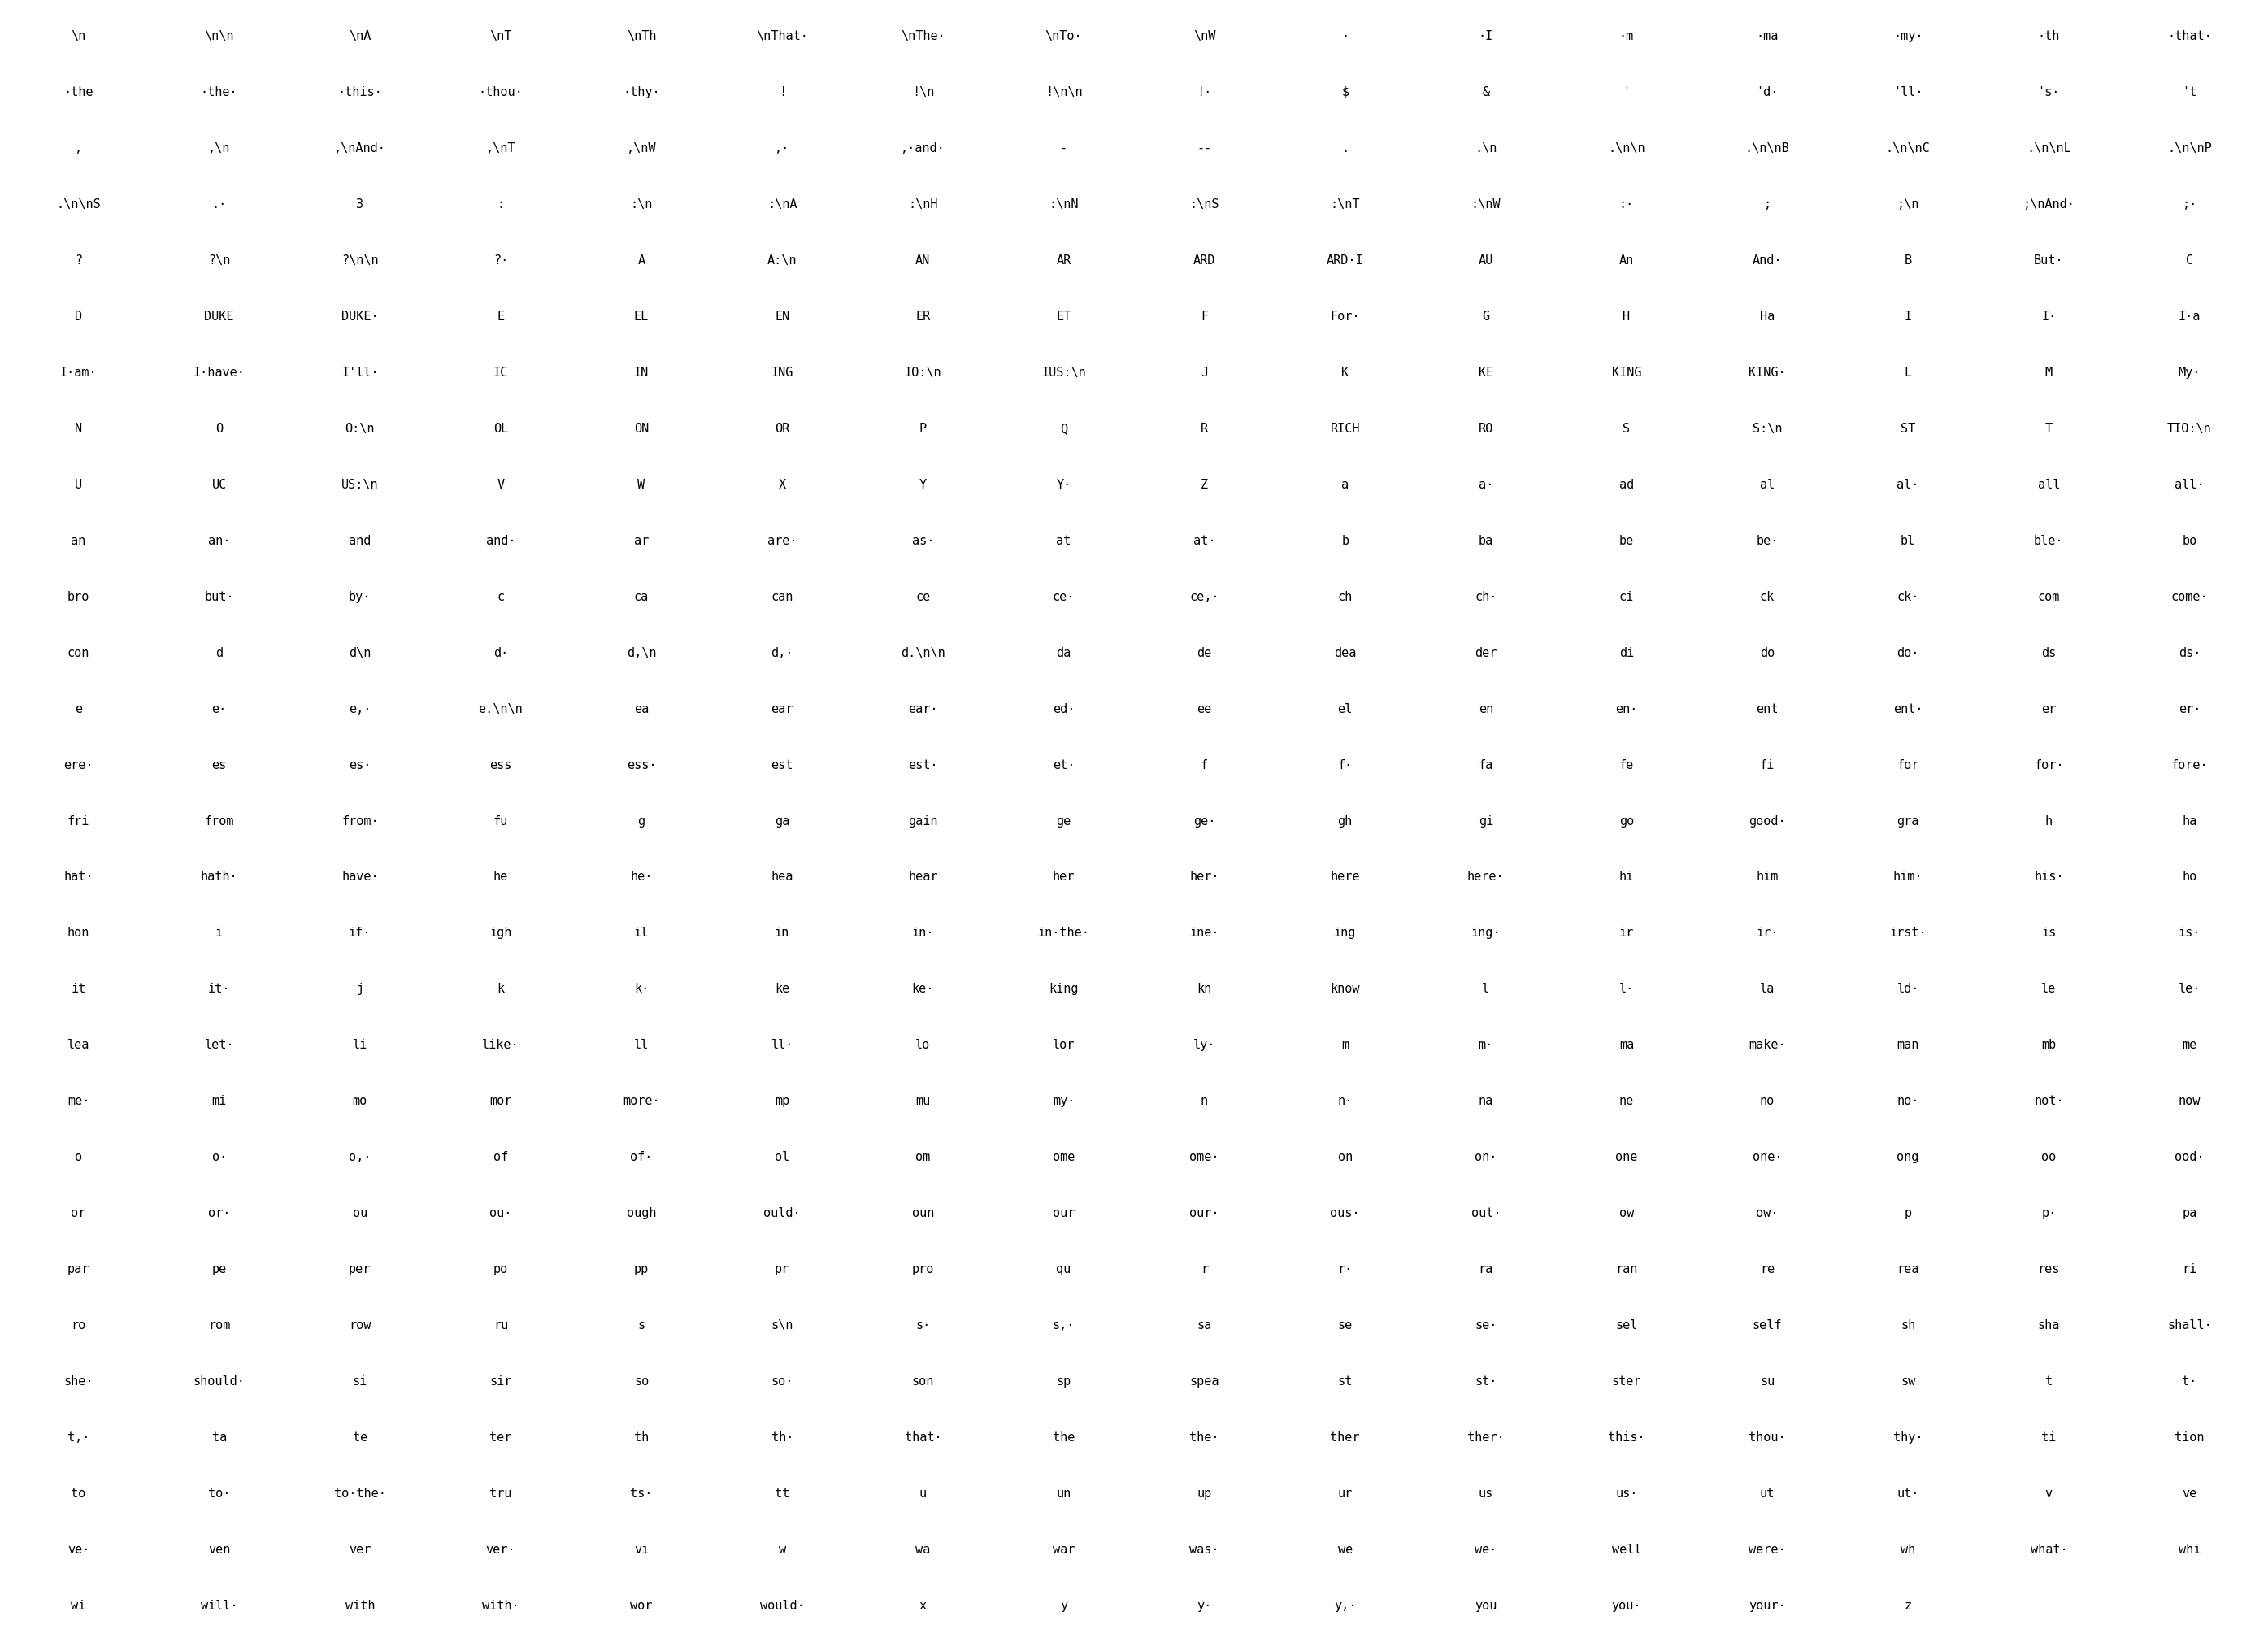

In [204]:
data_loader.plot_vocabulary()

In [205]:
x_train_indices, y_train_indices, x_test_indices, y_test_indices = data_loader.get_indices()

## Building the Model

In [206]:
embedding_dim = 128
hidden_size = 256
hidden2_size = 192

layer_definitions = [
    {"type": "Embedding", "num_embeddings": len(vocabulary), "embedding_dim": embedding_dim},
    {"type": "GatedRecurrent", "input_size": embedding_dim, "num_neurons": hidden_size},
    {"type": "Dropout"},
    {"type": "GatedRecurrent", "input_size": hidden_size, "num_neurons": hidden2_size},
    {"type": "Dropout"},
    {"type": "Softmax", "input_size": hidden2_size, "num_neurons": len(vocabulary)},
]

model = Network(layer_definitions=layer_definitions)
model.describe()


Network Architecture

Layer 1: EmbeddingLayer
  Embeddings Shape: (462, 128)
  Parameters: 59,136

Layer 2: GatedRecurrentLayer
  Weights Shape: (128, 256) | Recurrent Weights Shape: (256, 256) | Gates: 3
  Parameters: 295,680

Layer 3: DropoutLayer
  Rate: 0.2

Layer 4: GatedRecurrentLayer
  Weights Shape: (256, 192) | Recurrent Weights Shape: (192, 192) | Gates: 3
  Parameters: 258,624

Layer 5: DropoutLayer
  Rate: 0.2

Layer 6: SoftmaxLayer
  Weights Shape: (192, 462) | Biases Shape: (462,)
  Parameters: 89,166

Total Parameters: 702,606


## Training the Model

In [207]:
def one_hot(indices: cp.ndarray, num_classes: int) -> cp.ndarray:
    encoded = cp.zeros((indices.shape[0], num_classes), dtype=cp.float32)
    encoded[cp.arange(indices.shape[0]), indices] = 1.0
    return encoded

In [208]:
def reshape_streams(
    x_indices: cp.ndarray,
    y_indices: cp.ndarray,
    batch_size: int,
    max_columns: int | None = None,
 ) -> tuple[cp.ndarray, cp.ndarray]:
    usable_tokens = (x_indices.shape[0] // batch_size) * batch_size
    x = x_indices[:usable_tokens].reshape(batch_size, -1)
    y = y_indices[:usable_tokens].reshape(batch_size, -1)

    if max_columns is not None:
        x = x[:, :max_columns]
        y = y[:, :max_columns]

    return x, y

In [209]:
def evaluate(
    model: Network,
    x_indices: cp.ndarray,
    y_indices: cp.ndarray,
    batch_size: int,
    sequence_length: int,
    max_steps: int | None = None,
) -> float:
    x, y = reshape_streams(
        x_indices=x_indices,
        y_indices=y_indices,
        batch_size=batch_size,
        max_columns=max_steps,
    )

    model.reset_states(batch_size=batch_size, dtype=cp.float32)
    total_loss = 0.0
    total_steps = x.shape[1]

    for step in range(total_steps):
        y_prob = model.forward(x[:, step])[-1]
        y_true = one_hot(y[:, step], len(vocabulary))
        total_loss += float(model.cce_loss(y_prob, y_true).item())

        if (step + 1) % sequence_length == 0:
            model.reset_states(batch_size=batch_size, dtype=cp.float32)

    return math.exp(total_loss / total_steps)

In [210]:
def train_epoch(
    model: Network,
    x_indices: cp.ndarray,
    y_indices: cp.ndarray,
    batch_size: int,
    sequence_length: int,
    learning_rate: float,
    optimizer: AdamWOptimizer,
    max_steps: int | None = None,
    clip_value: float | None = None,
) -> float:
    model.set_training(True)
    x, y = reshape_streams(
        x_indices=x_indices,
        y_indices=y_indices,
        batch_size=batch_size,
        max_columns=max_steps,
    )
    model.reset_states(batch_size=batch_size, dtype=cp.float32)
    total_loss = 0.0
    total_steps = x.shape[1]

    for chunk_start in range(0, total_steps, sequence_length):
        chunk_end = min(chunk_start + sequence_length, total_steps)
        output_errors = []

        for step in range(chunk_start, chunk_end):
            y_prob = model.forward(x[:, step])[-1]
            y_true = one_hot(y[:, step], len(vocabulary))
            total_loss += float(model.cce_loss(y_prob, y_true).item())
            output_errors.append(y_prob - y_true)

        model.backward_sequence(output_errors, batch_size, clip_value=clip_value)
        optimizer.step(model, learning_rate)
        model.reset_states(batch_size=batch_size, dtype=cp.float32)

    model.set_training(False)
    return math.exp(total_loss / total_steps)


In [211]:
hyperparameters = {
    "sequence_length": 128,
    "batch_size": 64,
    "epochs": 1000,
    "train_steps_per_epoch": 4096,
    "validation_steps": 1024,
    "base_learning_rate": 1e-3,
    "min_learning_rate": 1e-5,
    "weight_decay_lambda": 2e-2,
    "beta1": 0.9,
    "beta2": 0.999,
    "epsilon": 1e-8,
    "early_stopping_patience": 100,
    "clip_value": 5.0,
    "checkpoint_interval": 50,
    "dropout_rate": 0.35
}

print(hyperparameters)

{'sequence_length': 128, 'batch_size': 64, 'epochs': 1000, 'train_steps_per_epoch': 4096, 'validation_steps': 1024, 'base_learning_rate': 0.001, 'min_learning_rate': 1e-05, 'weight_decay_lambda': 0.02, 'beta1': 0.9, 'beta2': 0.999, 'epsilon': 1e-08, 'early_stopping_patience': 100, 'clip_value': 5.0, 'checkpoint_interval': 50, 'dropout_rate': 0.35}


In [212]:
checkpoint_manager = CheckpointManager(file_name="gru_checkpoint.pkl")
best_model, epoch_summaries, best_perplexity = checkpoint_manager.load_checkpoint()

if best_model is not None:
    model = best_model.clone()

optimizer = AdamWOptimizer(
    beta1=hyperparameters["beta1"],
    beta2=hyperparameters["beta2"],
    epsilon=hyperparameters["epsilon"],
    weight_decay=hyperparameters["weight_decay_lambda"],
)

max_available_steps = int(x_train_indices.shape[0]) // hyperparameters["batch_size"]
train_steps_per_epoch = min(hyperparameters["train_steps_per_epoch"], max_available_steps)
if train_steps_per_epoch < hyperparameters["train_steps_per_epoch"]:
    print(f"Warning: train_steps_per_epoch clamped from {hyperparameters['train_steps_per_epoch']} to {train_steps_per_epoch} (data too short after BPE compression)")

model.update_dropout_rate(hyperparameters["dropout_rate"])

epoch_offset = len(epoch_summaries)
total_steps = (epoch_offset + hyperparameters["epochs"]) * train_steps_per_epoch
global_step = epoch_offset * train_steps_per_epoch
epochs_without_improvement = 0

slice_size = hyperparameters["batch_size"] * train_steps_per_epoch
max_offset = int(x_train_indices.shape[0]) - slice_size


No checkpoint found, starting from scratch.


In [213]:
for epoch in range(1, hyperparameters["epochs"] + 1):
    learning_rate = hyperparameters["min_learning_rate"] + 0.5 * (hyperparameters["base_learning_rate"] - hyperparameters["min_learning_rate"]) * (1 + math.cos(math.pi * global_step / total_steps))

    offset = random.randint(0, max_offset)
    x_slice = x_train_indices[offset : offset + slice_size]
    y_slice = y_train_indices[offset : offset + slice_size]

    train_perplexity = train_epoch(
        model=model,
        x_indices=x_slice,
        y_indices=y_slice,
        batch_size=hyperparameters["batch_size"],
        sequence_length=hyperparameters["sequence_length"],
        learning_rate=learning_rate,
        optimizer=optimizer,
        clip_value=hyperparameters["clip_value"],
    )
    test_perplexity = evaluate(
        model=model,
        x_indices=x_test_indices,
        y_indices=y_test_indices,
        batch_size=hyperparameters["batch_size"],
        sequence_length=hyperparameters["sequence_length"],
        max_steps=hyperparameters["validation_steps"],
    )

    epoch_summary = {
        "epoch": epoch + epoch_offset,
        "learning_rate": learning_rate,
        "train_perplexity": train_perplexity,
        "test_perplexity": test_perplexity,
        "regularization": train_perplexity / test_perplexity,
    }
    epoch_summaries.append(epoch_summary)

    if (epoch + epoch_offset) % 10 == 0 or epoch == 1:
        print(epoch_summary)

    if test_perplexity < best_perplexity:
        best_perplexity = test_perplexity
        best_model = model.clone()
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    global_step += train_steps_per_epoch

    if (epoch + epoch_offset) % hyperparameters["checkpoint_interval"] == 0:
        checkpoint_manager.save_checkpoint(best_model, vocabulary, epoch_summaries)

    if epochs_without_improvement >= hyperparameters["early_stopping_patience"]:
        print(f"Early stopping triggered after {epoch + epoch_offset} epochs due to no improvement.")
        break


{'epoch': 1, 'learning_rate': 0.001, 'train_perplexity': 370.14678232092626, 'test_perplexity': 301.1029181075597, 'regularization': 1.2293032051874795}
{'epoch': 10, 'learning_rate': 0.000999802152286877, 'train_perplexity': 60.03249470854634, 'test_perplexity': 45.441508726245026, 'regularization': 1.3210937838838568}
{'epoch': 20, 'learning_rate': 0.000999118437312715, 'train_perplexity': 39.308532821596266, 'test_perplexity': 32.20168523634221, 'regularization': 1.2206980017689697}
{'epoch': 30, 'learning_rate': 0.0009979470870965668, 'train_perplexity': 33.20170045153598, 'test_perplexity': 28.026092719303385, 'regularization': 1.1846710415208117}
{'epoch': 40, 'learning_rate': 0.0009962892576196778, 'train_perplexity': 29.57148148664942, 'test_perplexity': 25.997943926963444, 'regularization': 1.137454622170322}
{'epoch': 50, 'learning_rate': 0.000994146584959589, 'train_perplexity': 27.653286641779005, 'test_perplexity': 24.943641203213133, 'regularization': 1.108630709385638}
 

In [214]:
print(f"Best validation perplexity: {best_perplexity:.6f}")
checkpoint_manager.save_checkpoint(best_model, vocabulary, epoch_summaries)

Best validation perplexity: 23.778977
  Checkpoint saved -> checkpoints\gru_checkpoint.pkl


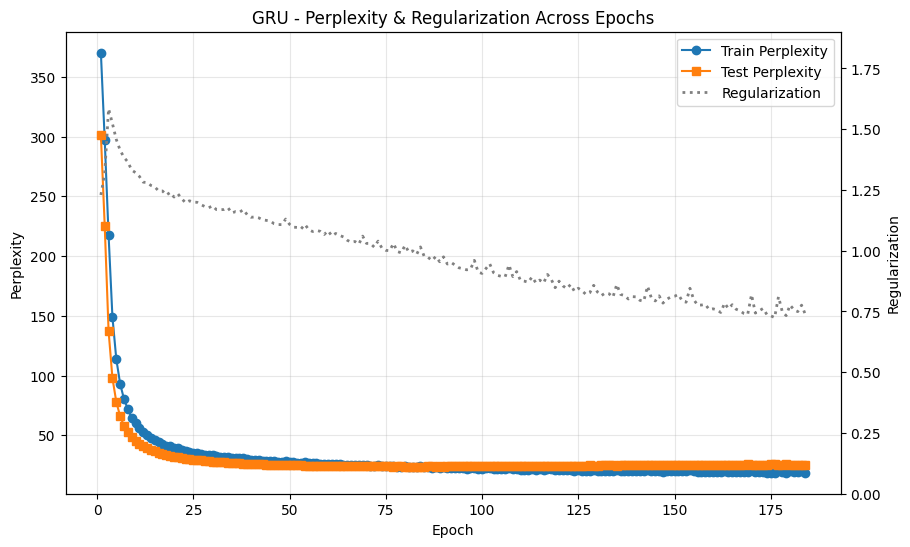

In [215]:
epochs_plot = [summary["epoch"] for summary in epoch_summaries]
train_perplexities = [summary["train_perplexity"] for summary in epoch_summaries]
test_perplexities = [summary["test_perplexity"] for summary in epoch_summaries]
regularizations = [summary["regularization"] for summary in epoch_summaries]

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(epochs_plot, train_perplexities, marker="o", label="Train Perplexity")
ax1.plot(epochs_plot, test_perplexities, marker="s", label="Test Perplexity")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Perplexity")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(epochs_plot, regularizations, color="gray", linestyle=":", linewidth=2, label="Regularization")
ax2.set_ylim(0, max(regularizations) * 1.2)
ax2.set_ylabel("Regularization")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)

plt.title("GRU - Perplexity & Regularization Across Epochs")
plt.show()

## Evaluating the Model

### Text Generation

In [225]:
eval_helper = EvaluationHelper(model=best_model, data_loader=data_loader, vocabulary=vocabulary)
generated_tokens = eval_helper.generate_text(seed_text="HAMLET", length=500, temperature=0.7)

HAMLET:
O, my lord. He was high indeed, they shall speak,
I am to merry. What may not fare.

MENENIUS:
He shall Of a mine
And little of himself and fool you good and bears,
Have intended on in men, I should hear?
Forthink to my breaks of the duke and gentle ford,
Unless you steels and great suppose remembering.

ESCALUS:
Thou dost say thy brother, love's he was your death,
Is this; I'll see the way, my lord, the burn,
For I would stars his much day mustishy, rest
Of all seven back a man, our gentleman.
O noble about to stand with a duke,
To like the young for whence shall be treachers
To take thee soft sent to their souls
Of pore is both hast my love,
That we do peace the greatly great orders,
Such secles, to be distance in death, but for a word.
O, sir, despairish, gentlemen, deliver'd up man
garried where I have fordther wrong-woe,
As let my fower, no kindn blood. The bone to a respect,
Let me remember than the tune of a prince.

GLOUCESTER:
By she not? let me be done.
What is the br

### Token Frequencies

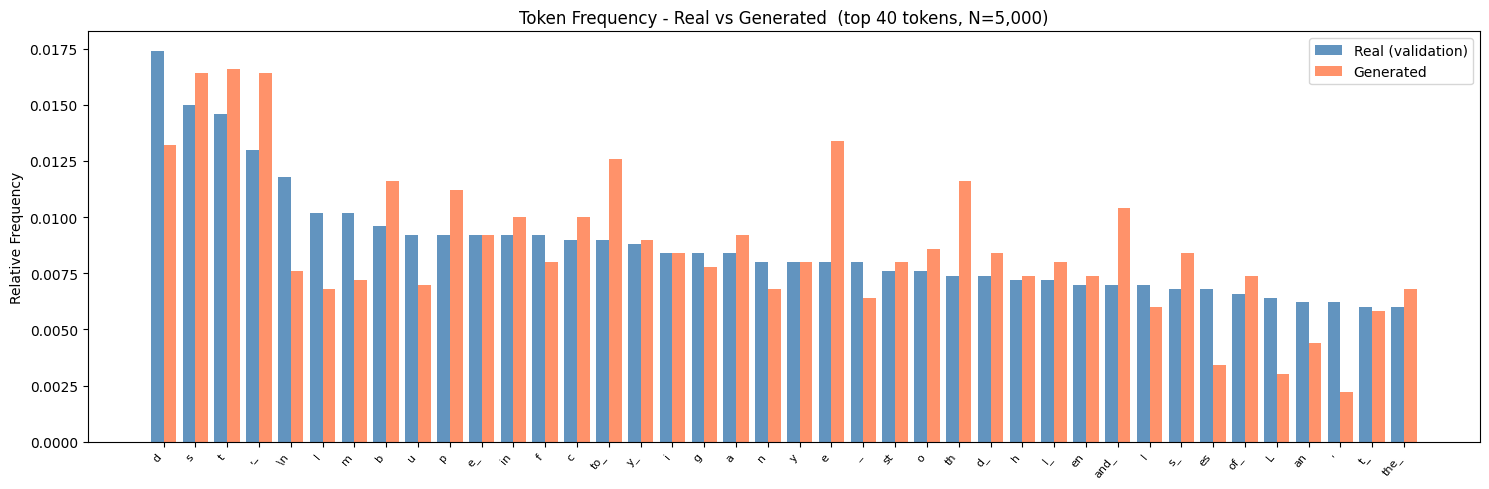

In [226]:
eval_helper.plot_token_frequencies(x_test_indices=x_test_indices)

### Embedding Spaces

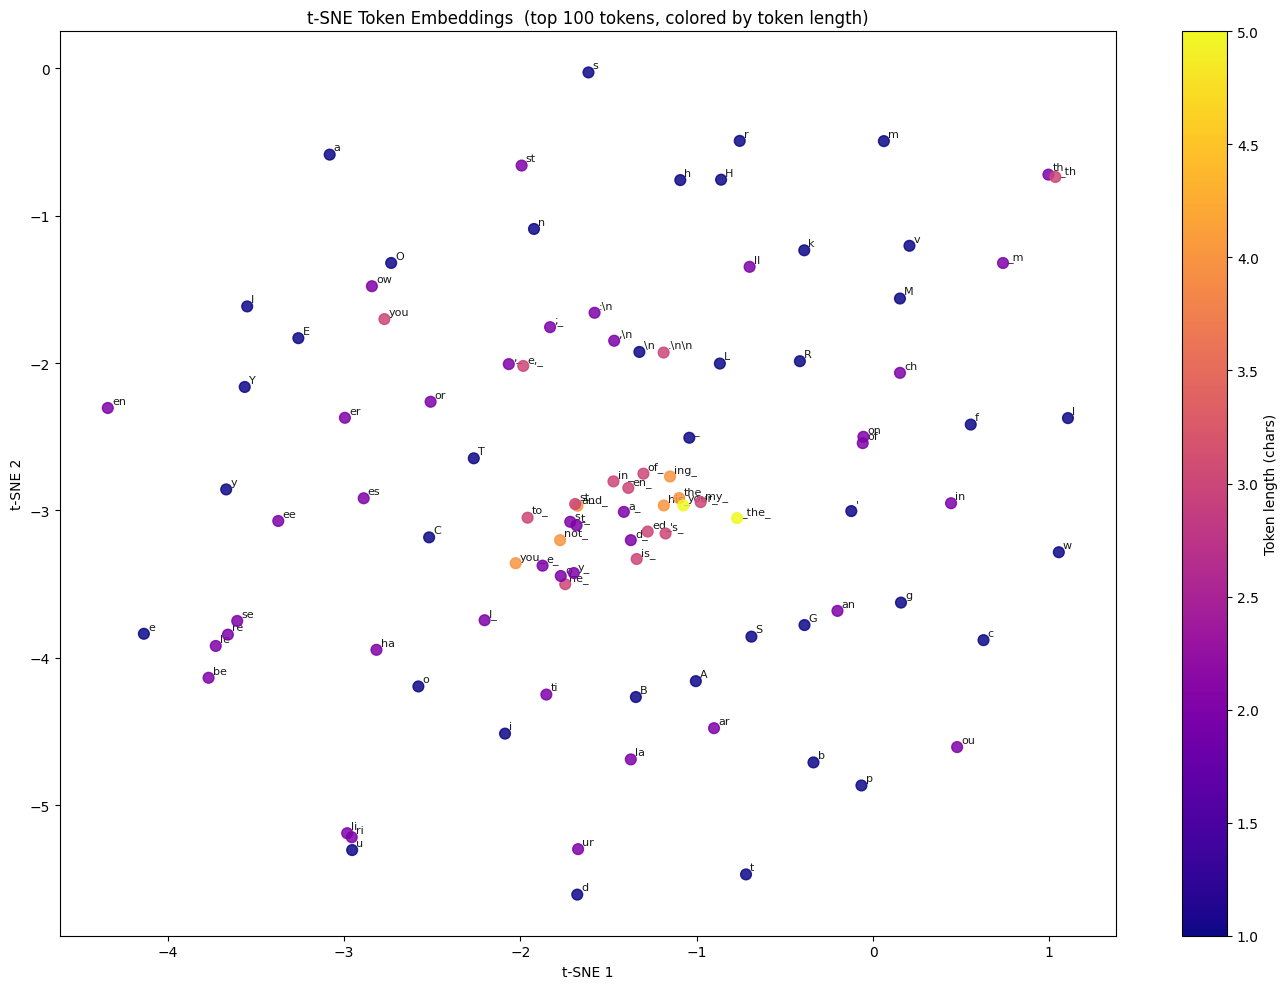

In [228]:
eval_helper.plot_embeddings_tsne(x_test_indices=x_test_indices)

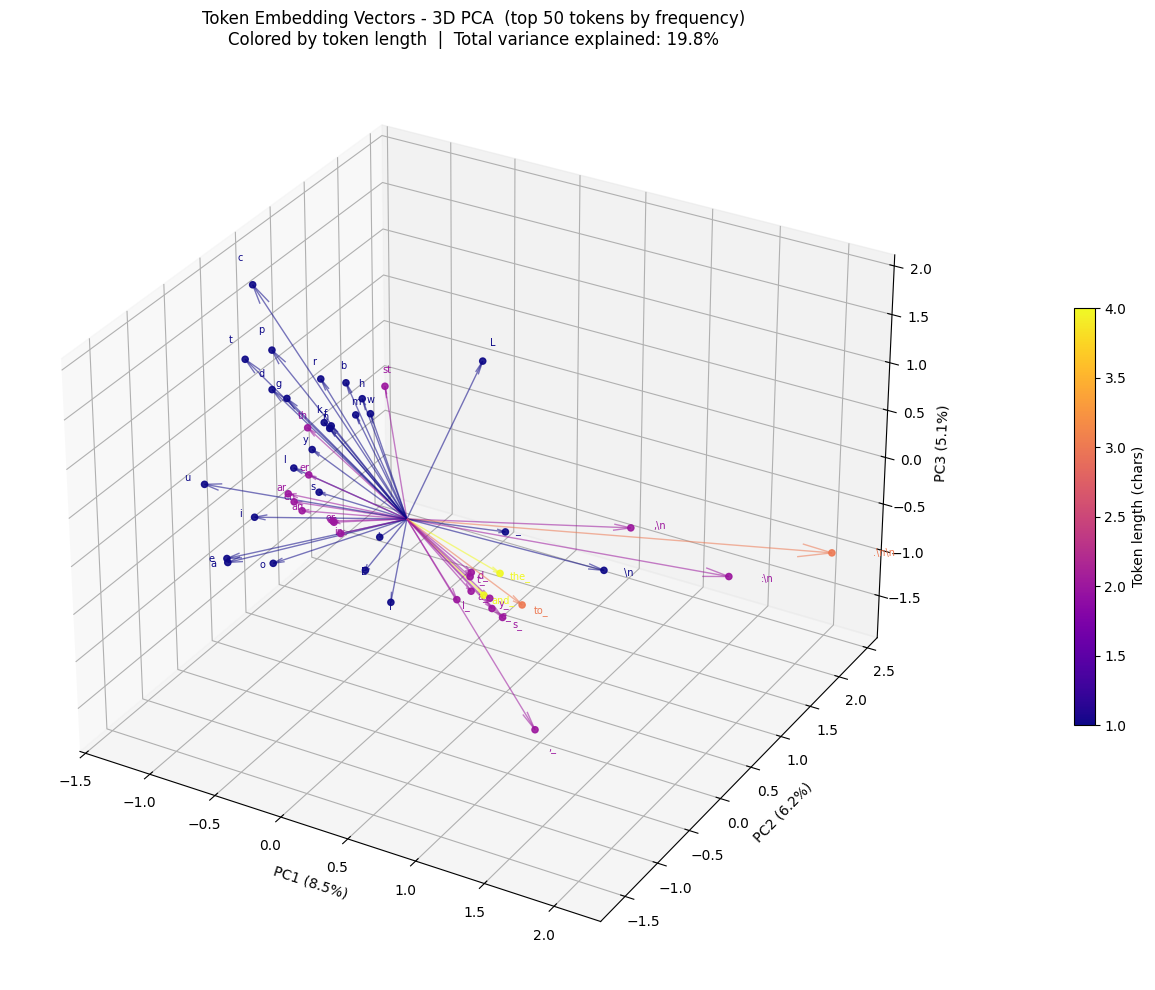

In [229]:
eval_helper.plot_embeddings_3d(x_test_indices=x_test_indices)

### Hidden State Trajectory

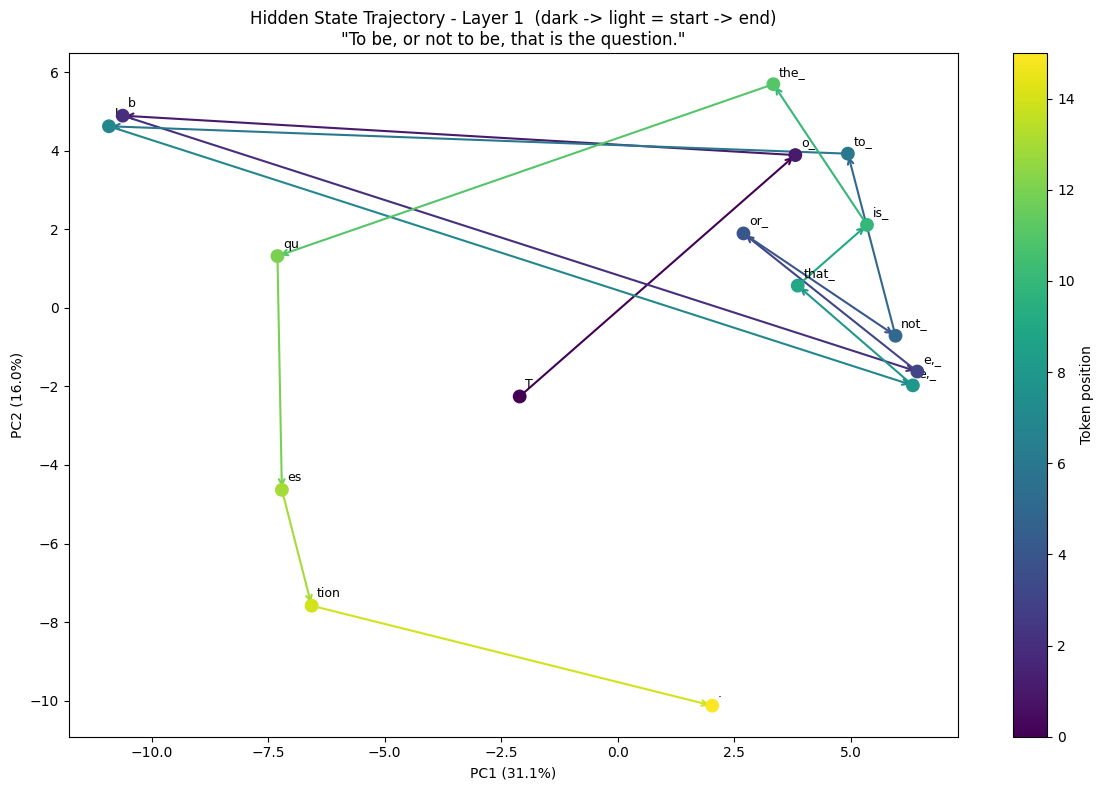

In [230]:
eval_helper.plot_hidden_state_trajectory(sentence="To be, or not to be, that is the question.")

### Temperature Sweep

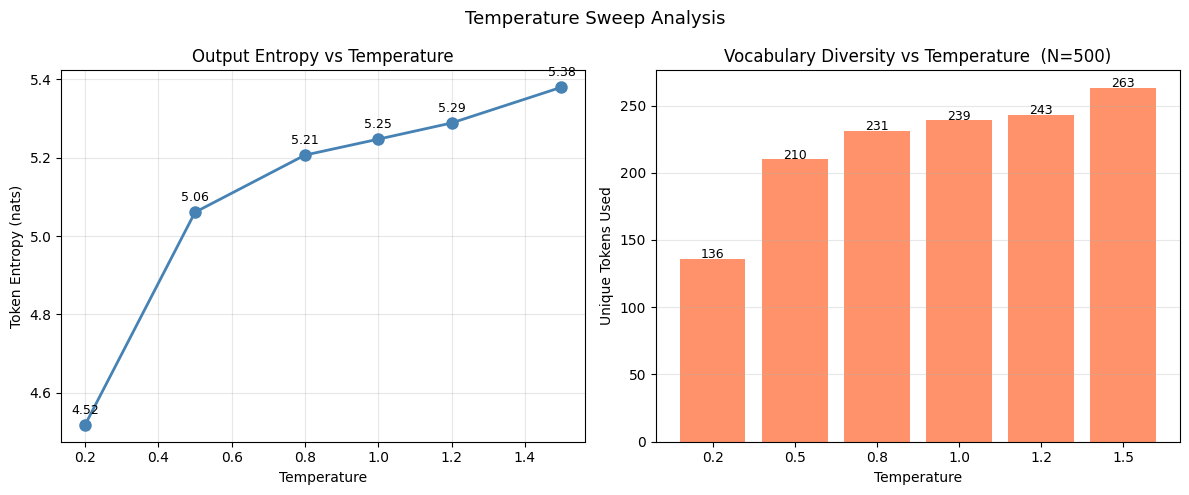

In [231]:
eval_helper.plot_temperature_sweep(seed_text="HAMLET")